In [19]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LinearRegression

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import matplotlib.pyplot as plt

In [20]:
df = pd.read_csv("driver_behavior.csv")

print(df.head())

   speed_kmph   accel_x   accel_y  brake_pressure  steering_angle  throttle  \
0   -1.646197 -0.677689  1.264479       -0.605615       -0.333874 -0.029914   
1   -1.502903 -0.228698 -1.078528       -0.084025       -2.575153 -0.817606   
2    0.859157  2.502836  1.549250        1.526413       -0.643518  1.145865   
3    1.937781  1.275730 -1.096786        0.218909        1.891133  1.366293   
4   -0.455938 -1.433722  0.742446       -0.016311       -0.432609  0.361065   

   lane_deviation  phone_usage  headway_distance  reaction_time  \
0        0.756130     1.414866         -0.503335       0.850947   
1        2.271441     1.414866          0.479102       0.912802   
2       -0.733058    -0.706781         -1.070117      -1.305385   
3        0.905243    -0.706781         -1.075191      -1.016568   
4        2.600000     1.414866         -0.175677       0.785500   

  behavior_label  behavior_label_encoded  
0     Distracted                       1  
1     Distracted                    

In [21]:
le = LabelEncoder()

df['behavior_label_encoded'] = le.fit_transform(df['behavior_label'])

print("\nEncoded Classes:")
print(dict(zip(le.classes_, le.transform(le.classes_))))


Encoded Classes:
{'Aggressive': np.int64(0), 'Distracted': np.int64(1), 'Safe': np.int64(2)}


In [22]:
X = df[[
    'speed_kmph',
    'accel_x',
    'accel_y',
    'brake_pressure',
    'steering_angle',
    'throttle',
    'lane_deviation',
    'phone_usage',
    'headway_distance',
    'reaction_time'
]]

y = df['behavior_label_encoded']

In [23]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [24]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42
)

print("\nTraining Shape:", X_train.shape)
print("Testing Shape:", X_test.shape)


Training Shape: (22124, 10)
Testing Shape: (5532, 10)


In [25]:
model = LinearRegression()

model.fit(X_train, y_train)

print("\nModel Trained Successfully!")


Model Trained Successfully!


In [26]:
y_pred = model.predict(X_test)

print("\nPredicted Values:")
print(y_pred[:10])


Predicted Values:
[ 0.95717148  0.04170061  1.80528656 -0.32256012  0.82959516  0.26828845
  1.15826294  2.04359318 -0.39126037  1.11377871]


In [27]:
mae = mean_absolute_error(y_test, y_pred)

mse = mean_squared_error(y_test, y_pred)

rmse = np.sqrt(mse)

r2 = r2_score(y_test, y_pred)

print("\n===== MODEL EVALUATION =====")

print("Mean Absolute Error (MAE):", mae)

print("Mean Squared Error (MSE):", mse)

print("Root Mean Squared Error (RMSE):", rmse)

print("R2 Score:", r2)


===== MODEL EVALUATION =====
Mean Absolute Error (MAE): 0.163056404688618
Mean Squared Error (MSE): 0.04255215131162011
Root Mean Squared Error (RMSE): 0.20628172801200814
R2 Score: 0.9359063352436642


In [28]:
comparison = pd.DataFrame({
    'Actual': y_test.values,
    'Predicted': y_pred
})

print("\nActual vs Predicted:")
print(comparison.head(10))


Actual vs Predicted:
   Actual  Predicted
0       1   0.957171
1       0   0.041701
2       2   1.805287
3       0  -0.322560
4       1   0.829595
5       0   0.268288
6       1   1.158263
7       2   2.043593
8       0  -0.391260
9       1   1.113779


In [29]:
coefficients = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_
})

print("\nFeature Coefficients:")
print(coefficients)


Feature Coefficients:
            Feature  Coefficient
0        speed_kmph    -0.062017
1           accel_x    -0.166826
2           accel_y    -0.072833
3    brake_pressure    -0.209017
4    steering_angle    -0.001477
5          throttle    -0.181945
6    lane_deviation    -0.044498
7       phone_usage    -0.169831
8  headway_distance     0.179743
9     reaction_time     0.131525


In [30]:
print("\nIntercept:")
print(model.intercept_)


Intercept:
1.0555331117812448


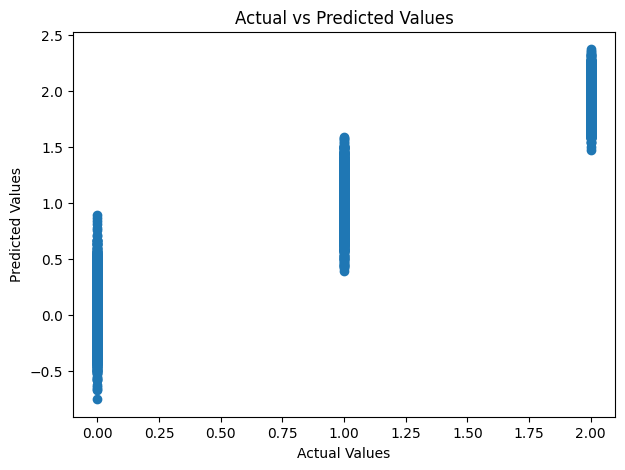

In [31]:
plt.figure(figsize=(7,5))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual Values")

plt.ylabel("Predicted Values")

plt.title("Actual vs Predicted Values")

plt.show()

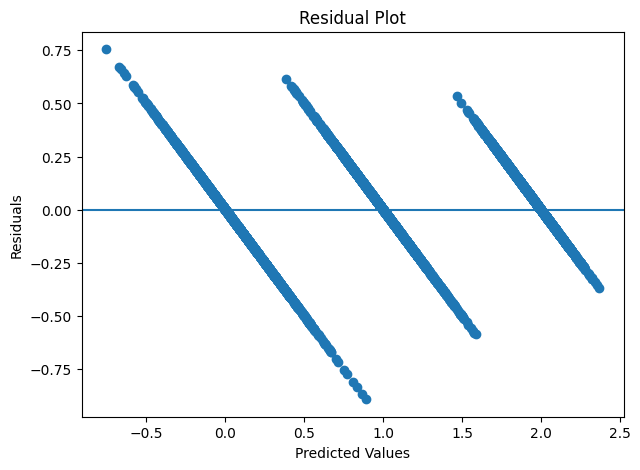

In [32]:
residuals = y_test - y_pred

plt.figure(figsize=(7,5))

plt.scatter(y_pred, residuals)

plt.axhline(y=0)

plt.xlabel("Predicted Values")

plt.ylabel("Residuals")

plt.title("Residual Plot")

plt.show()

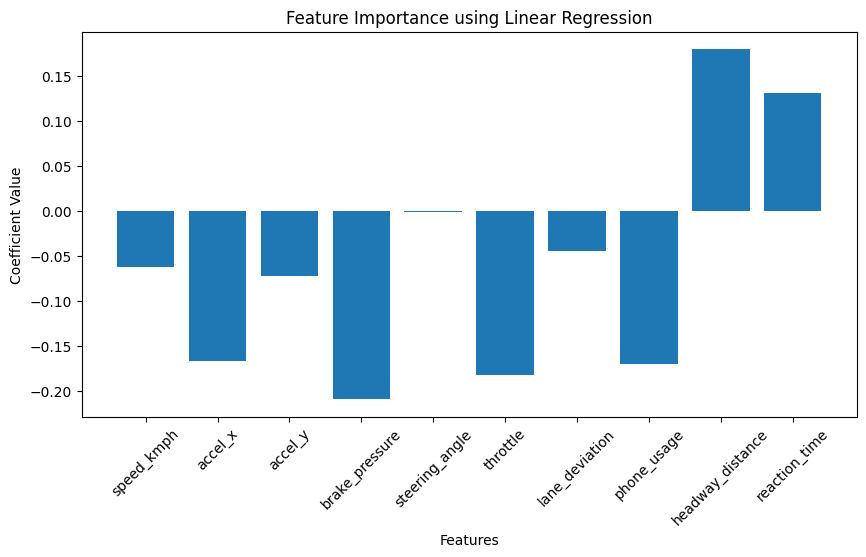

In [33]:
plt.figure(figsize=(10,5))

plt.bar(X.columns, model.coef_)

plt.xticks(rotation=45)

plt.xlabel("Features")

plt.ylabel("Coefficient Value")

plt.title("Feature Importance using Linear Regression")

plt.show()

In [34]:
sample_data = [[
    36.07,     # speed_kmph
    0.53,      # accel_x
    0.70,      # accel_y
    23.10,     # brake_pressure
    -3.16,     # steering_angle
    53.12,     # throttle
    0.85,      # lane_deviation
    1,         # phone_usage
    17.99,     # headway_distance
    1.40       # reaction_time
]]

sample_scaled = scaler.transform(sample_data)

prediction = model.predict(sample_scaled)

print("\nPredicted Encoded Behavior:")
print(prediction)


Predicted Encoded Behavior:
[-12.59928117]


c:\Users\rithi\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [35]:
comparison.to_csv("linear_regression_predictions.csv", index=False)

print("\nPredictions saved successfully!")


Predictions saved successfully!
